## **Import Libraris**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/phone_price_train.csv')
train=train_data.copy()
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## **EDA**

In [ ]:
print(f'the number of rows in the data is: {train.shape[0]}')
print(f'the number of columns in the data is: {train.shape[1]}')

the number of rows in the data is: 2000
the number of columns in the data is: 21


In [ ]:
print(f'names of the features in the data is : {train.columns}')

names of the features in the data is : Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
train.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [ ]:
X=train.drop(['price_range'],axis=1)
y=train['price_range']

In [ ]:
for feature in X.columns:
  print(f'Unique V in features {feature}are: {X[feature].unique()} (total is {X[feature].nunique()}).\n')

Unique V in features battery_powerare: [ 842 1021  563 ... 1139 1467  858] (total is 1094).

Unique V in features blueare: [0 1] (total is 2).

Unique V in features clock_speedare: [2.2 0.5 2.5 1.2 1.7 0.6 2.9 2.8 2.1 1.  0.9 1.1 2.6 1.4 1.6 2.7 1.3 2.3
 2.  1.8 3.  1.5 1.9 2.4 0.8 0.7] (total is 26).

Unique V in features dual_simare: [0 1] (total is 2).

Unique V in features fcare: [ 1  0  2 13  3  4  5  7 11 12 16  6 15  8  9 10 18 17 14 19] (total is 20).

Unique V in features four_gare: [0 1] (total is 2).

Unique V in features int_memoryare: [ 7 53 41 10 44 22 24  9 33 17 52 46 13 23 49 19 39 47 38  8 57 51 21  5
 60 61  6 11 50 34 20 27 42 40 64 14 63 43 16 48 12 55 36 30 45 29 58 25
  3 54 15 37 31 32  4 18  2 56 26 35 59 28 62] (total is 63).

Unique V in features m_depare: [0.6 0.7 0.9 0.8 0.1 0.5 1.  0.3 0.4 0.2] (total is 10).

Unique V in features mobile_wtare: [188 136 145 131 141 164 139 187 174  93 182 177 159 198 185 196 121 101
  81 156 199 114 111 132 143  96 200  88

# **Split Categorial / Nomerical for Visualisation**

In [ ]:
cat_feat=[]
for feature in X.columns:
  if X[feature].nunique()<=5:
    cat_feat.append(feature)
num_feat=list(set(X.columns)-set(cat_feat))

In [ ]:
print(f'Categorical features are: {cat_feat}(total is {len (cat_feat)})\n')
print(f'Numerical features are: {num_feat} )total is {len (num_feat)}\n')

Categorical features are: ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi'](total is 6)

Numerical features are: ['pc', 'sc_h', 'battery_power', 'fc', 'm_dep', 'ram', 'talk_time', 'clock_speed', 'n_cores', 'mobile_wt', 'int_memory', 'px_width', 'sc_w', 'px_height'] )total is 14



# **Visuals**

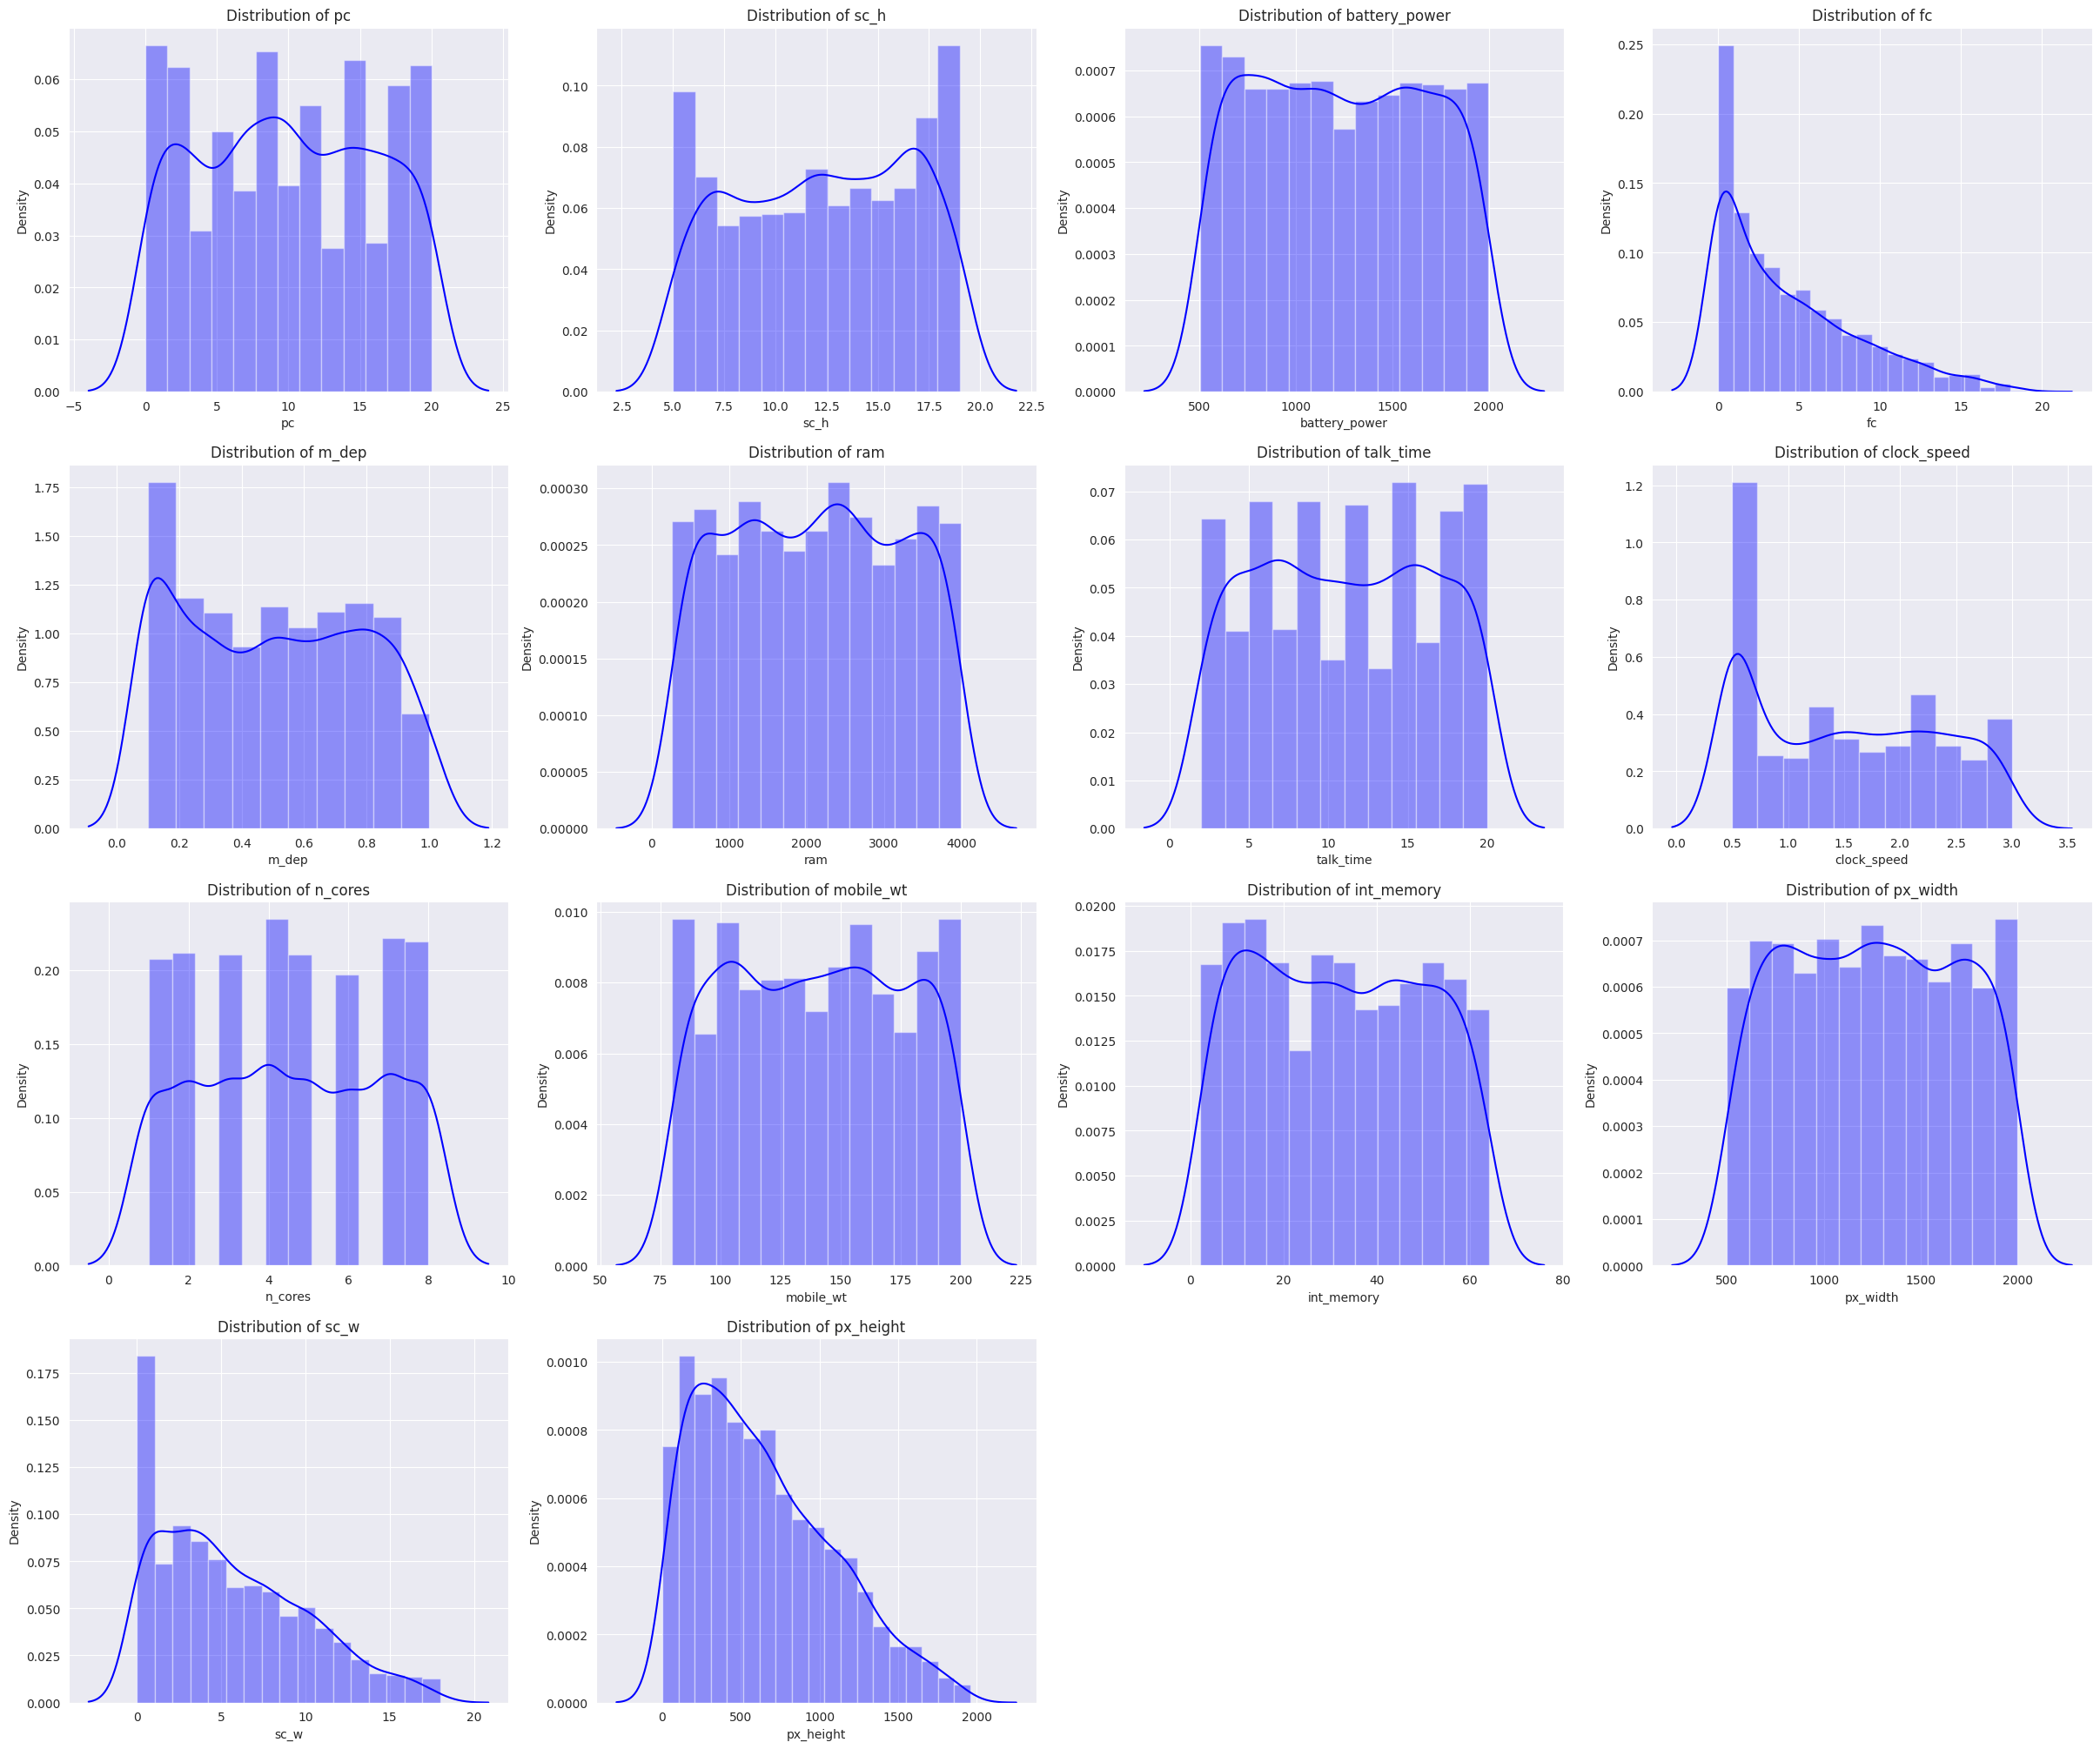

In [ ]:
plt.figure(figsize=(30,25))
sns.set_style('darkgrid')

for index, feature in enumerate(num_feat):
  plt.subplot(4,4,index+1)
  sns.distplot(X[feature], kde= True,color='b')
  plt.xlabel(feature)
  plt.title(f'Distribution of {feature}')

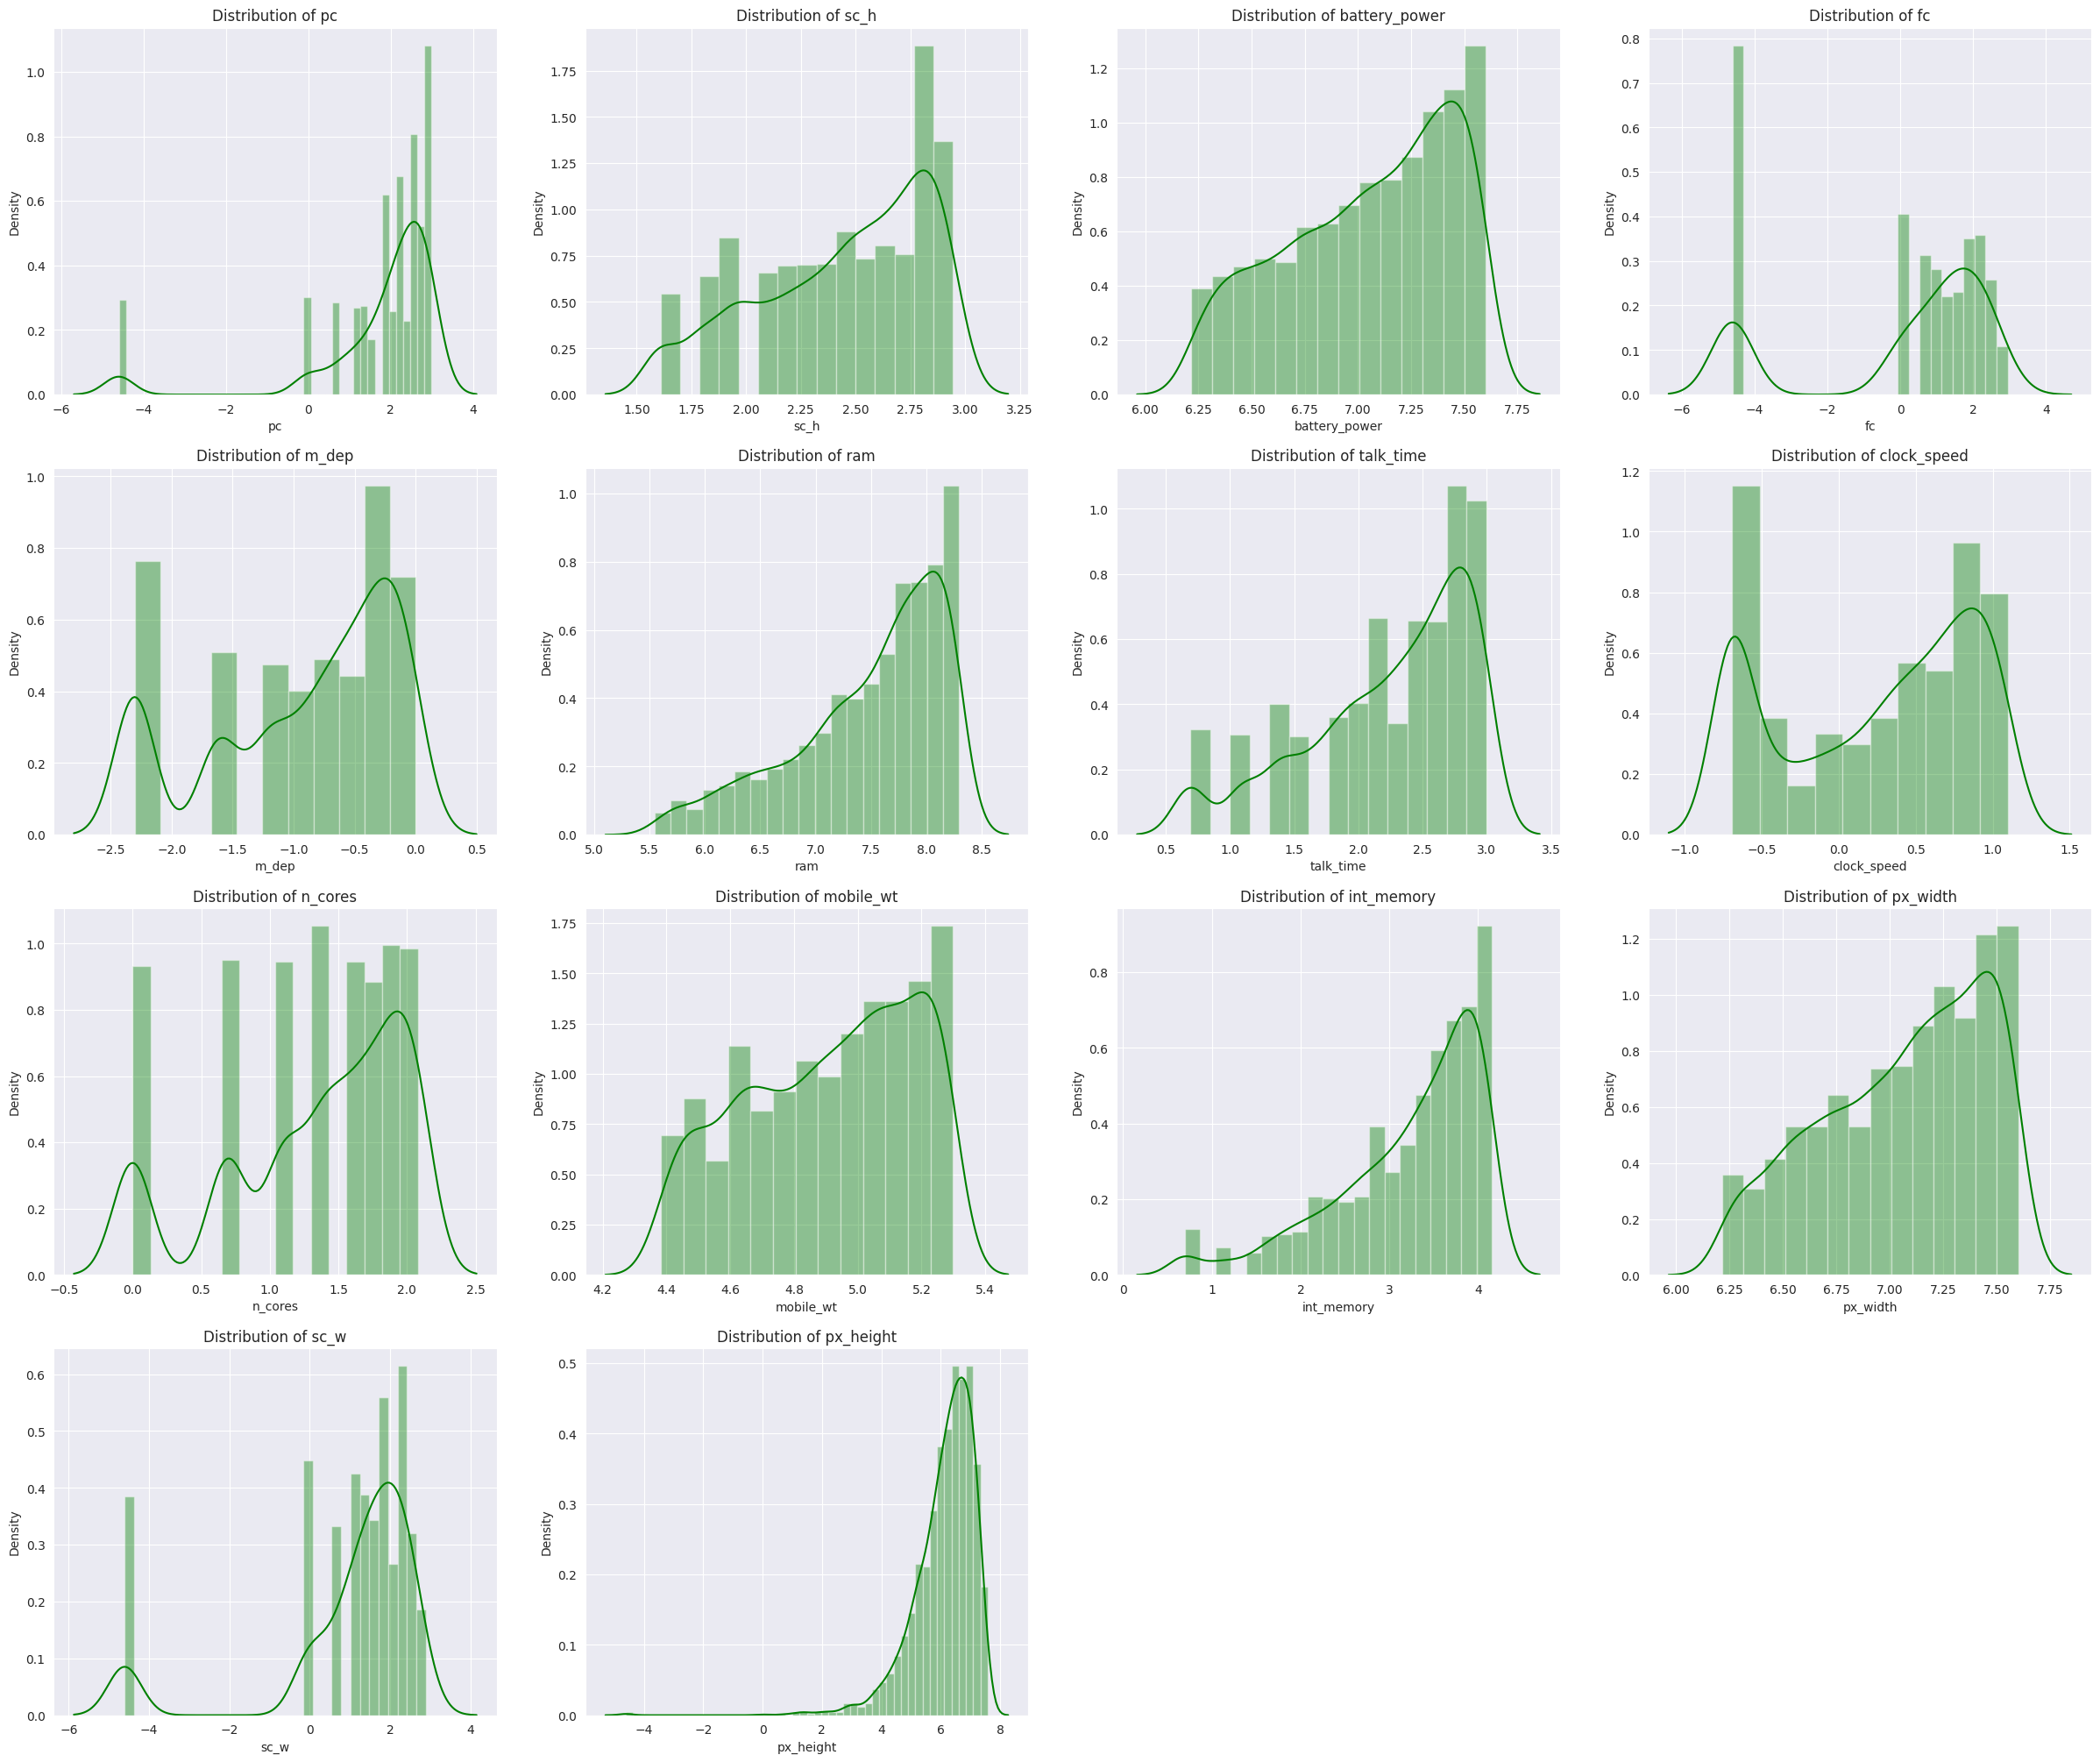

In [ ]:
plt.figure(figsize=(30,25))
sns.set_style('darkgrid')

for index, feature in enumerate(num_feat):
  plt.subplot(4,4,index+1)
  data=np.where(X[feature]==0,X[feature]+0.01,X[feature])
  sns.distplot(np.log(data), kde= True,color='g')
  plt.xlabel(feature)
  plt.title(f'Distribution of {feature}')

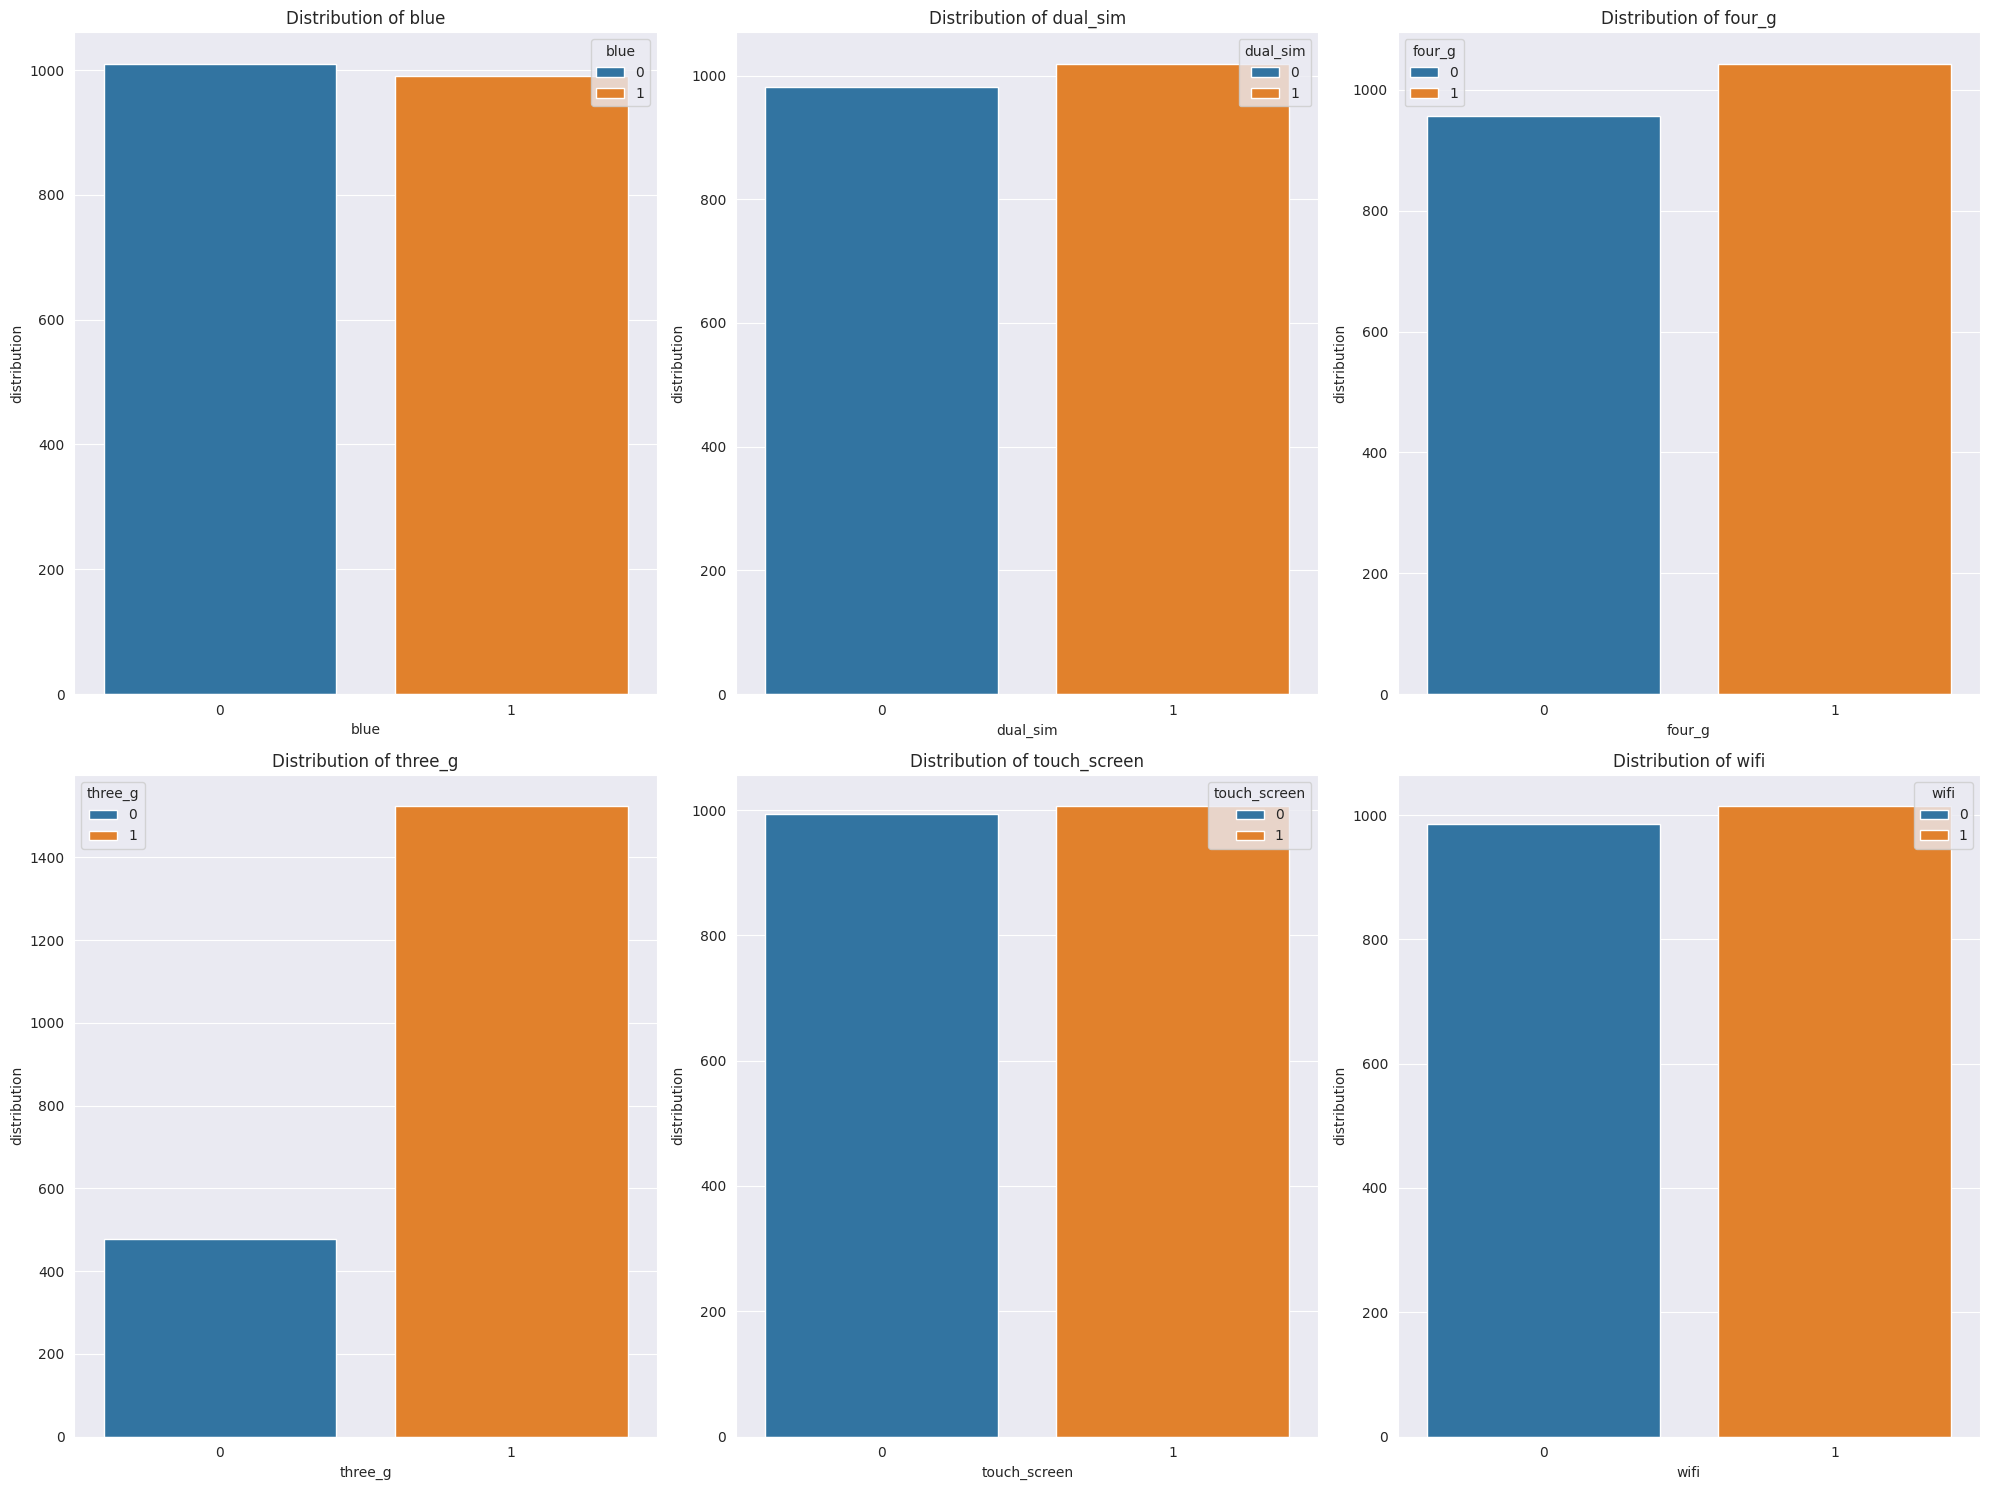

In [ ]:
plt.figure(figsize=(20, 15))
sns.set_style('darkgrid')

for index, feature in enumerate(cat_feat):
    ax = plt.subplot(2, 3, index + 1)
    sns.countplot(x=feature, data=X, ax=ax,hue=feature)

    ax.set_xlabel(feature)
    ax.set_ylabel('distribution')
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

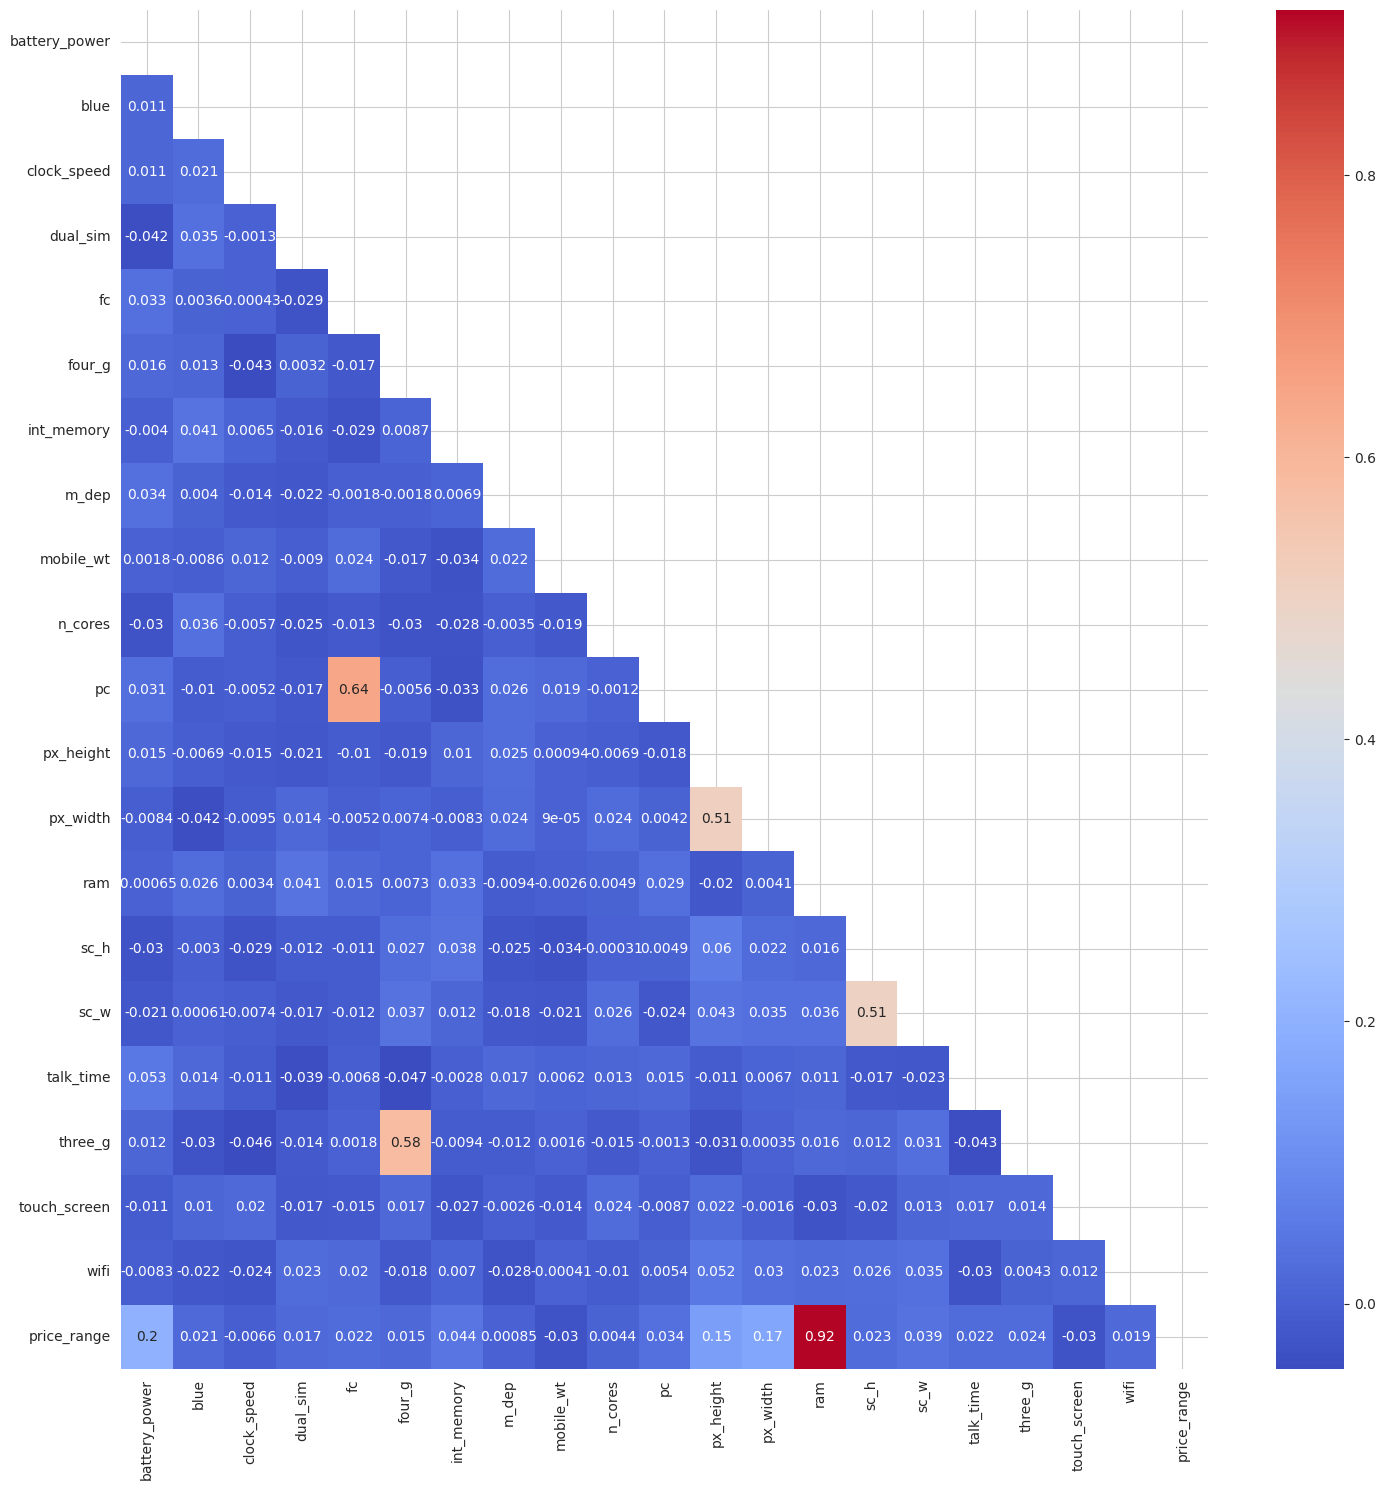

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('whitegrid')
corr=train.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,annot=True,cmap='coolwarm',mask=mask)
plt.tight_layout()
plt.show()

# **Build the model for price prediction**

In [ ]:
from sklearn.model_selection import cross_val_score,KFold
from sklearn.ensemble import RandomForestRegressor

kf= KFold(n_splits=10)
cvs=cross_val_score(estimator=RandomForestRegressor(max_depth=4,random_state=42),X=X,y=y,scoring='r2',cv=kf)
print(f'The cross valdiation score of the train data is {np.round(np.mean(cvs),2)} +/- {np.round(cvs.std(),2)}.')

The cross valdiation score of the train data is 0.91 +/- 0.01.


In [ ]:
#training the model

RF=RandomForestRegressor(max_depth=4,random_state=23)
model=RF.fit(X,y)
y_pred=model.predict(X)
y_pred

array([1.65884684, 1.95841247, 1.90621312, ..., 2.80367278, 0.06813502,
       2.3796191 ])

In [ ]:
#test the model on test_file data
test=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/phone_price_test.csv')

In [ ]:
test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [ ]:
prediction=pd.DataFrame()
prediction['id']=test['id']

In [ ]:
test.drop('id',axis=1,inplace=True)
prediction['price_range']=model.predict(test)
prediction.head()

,id,price_range
0,1,2.940604
1,2,2.826921
2,3,2.587343
3,4,2.979469
4,5,1.125131
